In [10]:
import time
import requests
import pandas as pd

In [ ]:
def whoami(proxies):
    """Ask ip-api.com what IP / location the server sees for this route."""
    r = requests.get("http://ip-api.com/json", proxies=proxies, timeout=20).json()
    return {
        "IP seen by server": r.get("query"),
        "City": r.get("city"),
        "Region": r.get("regionName"),
        "Country": r.get("country"),
        "ISP": r.get("isp"),
    }


print({"Route": "NO PROXY (your real IP)", **whoami(None)})

## Setup — configure the proxies

In [ ]:

# --- Proxy-Seller IPv4 proxies (same account as process_1.ipynb) ---
PROXY_LOGIN = "your_username"
PROXY_PASSWORD = "your_password"
PROXY_PORT = '' # http/https port
PROXY_IPS = [
    "ip-1",
    "ip-2",
    "ip-3",
]

def proxy_dict(ip):
    """Build a requests-style proxies dict for one proxy IP."""
    url = f"http://{PROXY_LOGIN}:{PROXY_PASSWORD}@{ip}:{PROXY_PORT}"
    return {"http": url, "https": url}

# None here means 'no proxy -> connect directly from your own IP'.
DIRECT = None

print(f"Configured {len(PROXY_IPS)} proxies:", PROXY_IPS)

## Impact-1 — Identity & Location

Every request tells the website which IP it came from, and the IP reveals your
approximate **city, region and ISP**. Let's ask a free geolocation API
(`ip-api.com`) *who it thinks we are*, first directly and then through each proxy.

In [ ]:
def whoami(proxies):
    """Ask ip-api.com what IP / location the server sees for this route."""
    r = requests.get("http://ip-api.com/json", proxies=proxies, timeout=20).json()
    return {
        "IP seen by server": r.get("query"),
        "City": r.get("city"),
        "Region": r.get("regionName"),
        "Country": r.get("country"),
        "ISP": r.get("isp"),
    }

rows = []
rows.append({"Route": "NO PROXY (your real IP)", **whoami(DIRECT)})
for ip in PROXY_IPS:
    rows.append({"Route": f"via proxy {ip}", **whoami(proxy_dict(ip))})

identity = pd.DataFrame(rows)
identity

**Read the table above.** The `NO PROXY` row shows *your* real IP, city and ISP —
that is exactly what every site you scrape without a proxy can see and log. Each
`via proxy` row shows a completely different IP, city and ISP. That is the first
impact: **without a proxy you have no anonymity — the target sees your true identity
and location.**

## Impact-2 — Getting IP-Blocked (Rate Limiting)

This is the impact that actually breaks scrapers. Most real sites **count requests
per IP** and block you once you exceed a limit.



In [ ]:
# A normal endpoint that DOES count against the 60/hour-per-IP limit.
GITHUB_URL = "https://api.github.com/users/octocat"

def check_quota(proxies):
    """Return (remaining, limit, status) for one request through this route."""
    r = requests.get(GITHUB_URL, proxies=proxies, timeout=20)
    remaining = int(r.headers.get("X-RateLimit-Remaining", -1))
    limit = int(r.headers.get("X-RateLimit-Limit", -1))
    return remaining, limit, r.status_code

print("GitHub allows 60 unauthenticated requests per HOUR, counted PER IP.\n")

rem, lim, _ = check_quota(DIRECT)
print(f"Your real IP           -> {rem:>3}/{lim} left this hour")
capacity = lim
for ip in PROXY_IPS:
    rem, lim, _ = check_quota(proxy_dict(ip))
    print(f"Proxy {ip:<16} -> {rem:>3}/{lim} left this hour")
    capacity += lim

print(f"\nWithout a proxy you have ONE bucket:  60 requests/hour.")
print(f"With your 3 proxies + direct you have {capacity} requests/hour ({capacity // 60}x the capacity).")

### 2a. The block, live



In [15]:
RUN_BLOCK_TEST = True     # set to False to skip the quota-consuming test
REQUESTS_TO_FIRE = 75     # > 60 so a single IP visibly gets blocked

def fire_requests(n, rotate):
    """Fire n requests. rotate=False -> all direct; rotate=True -> cycle proxies."""
    succeeded = blocked = 0
    for i in range(n):
        proxies = proxy_dict(PROXY_IPS[i % len(PROXY_IPS)]) if rotate else DIRECT
        try:
            r = requests.get(GITHUB_URL, proxies=proxies, timeout=20)
            if r.status_code == 200:
                succeeded += 1
            else:  # 403 / 429 = rate-limited / blocked
                blocked += 1
        except requests.RequestException:
            blocked += 1
    return succeeded, blocked

if RUN_BLOCK_TEST:
    print(f"Firing {REQUESTS_TO_FIRE} requests WITHOUT a proxy (one IP)...")
    ok_direct, blk_direct = fire_requests(REQUESTS_TO_FIRE, rotate=False)
    print(f"   -> {ok_direct} succeeded, {blk_direct} BLOCKED (HTTP 403)\n")

    print(f"Firing {REQUESTS_TO_FIRE} requests WITH proxy rotation (3 IPs)...")
    ok_proxy, blk_proxy = fire_requests(REQUESTS_TO_FIRE, rotate=True)
    print(f"   -> {ok_proxy} succeeded, {blk_proxy} blocked")
else:
    print("Skipped (RUN_BLOCK_TEST = False).")

Firing 75 requests WITHOUT a proxy (one IP)...
   -> 58 succeeded, 17 BLOCKED (HTTP 403)

Firing 75 requests WITH proxy rotation (3 IPs)...
   -> 75 succeeded, 0 blocked


### 2b. Compare the two scenarios

,Scenario,Succeeded,Blocked
0,WITHOUT proxy (1 IP),58,17
1,WITH proxy rotation (3 IPs),75,0


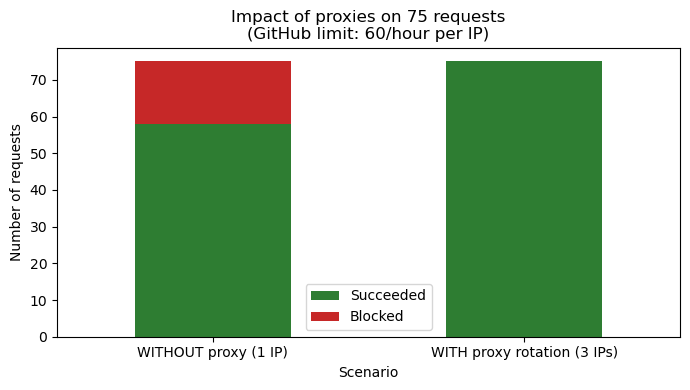

In [16]:
if RUN_BLOCK_TEST:
    summary = pd.DataFrame([
        {"Scenario": "WITHOUT proxy (1 IP)",        "Succeeded": ok_direct, "Blocked": blk_direct},
        {"Scenario": "WITH proxy rotation (3 IPs)", "Succeeded": ok_proxy,  "Blocked": blk_proxy},
    ])
    display(summary)

    try:
        import matplotlib.pyplot as plt
        ax = summary.set_index("Scenario")[["Succeeded", "Blocked"]].plot(
            kind="bar", stacked=True, color=["#2e7d32", "#c62828"], figsize=(7, 4))
        ax.set_ylabel("Number of requests")
        ax.set_title(f"Impact of proxies on {REQUESTS_TO_FIRE} requests\n(GitHub limit: 60/hour per IP)")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("(chart skipped:", e, ")")
else:
    print("Nothing to compare (RUN_BLOCK_TEST = False).")